# Session 6, Notebook 2: Gaussian-Process Regression

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 09:00-09:50, Deep surrogates and Gaussian processes
**Slides:** `06_Deep_Surrogates_and_GPs.pdf`
**Author:** Simon Scheidegger (HEC, University of Lausanne)

In [1]:
RUN_MODE = "teaching"  # one of: "smoke", "teaching", "production"
SEED = 0

Gaussian-process regression in the order the slides present it: a prior over functions defined
by a kernel, the posterior obtained by conditioning a Gaussian, and the two things that must be
chosen, the kernel and its hyperparameters. Everything is first written out in numpy, then checked
against scikit-learn, which adds the marginal-likelihood fit of the hyperparameters.

| Section | Content |
|:--|:--|
| 1 | The kernel and samples from the prior |
| 2 | The posterior in two lines, from scratch |
| 3 | The length scale, too short and too long; noise and jitter |
| 4 | scikit-learn: hyperparameters by marginal likelihood, RBF against Matérn on a kink |
| 5 | Two inputs: the surrogate of Notebook 1 with one length scale per input |
| 6 | Active learning: let the posterior variance choose the next point, on the Runge function |

In [2]:
# ----------------------------------------------------------------
# Imports and plot style
# ----------------------------------------------------------------
import time, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.linalg import cho_factor, cho_solve
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern

warnings.filterwarnings("ignore", category=ConvergenceWarning)
rng = np.random.default_rng(SEED)

rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                 "legend.fontsize": 9, "font.family": "serif", "mathtext.fontset": "cm",
                 "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
C_TRUE, C_GP, C_PTS = "#264653", "#2a9d8f", "#e76f51"

FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = (RUN_MODE == "teaching")
def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")

N_BAL = {"smoke": 6, "teaching": 8, "production": 12}[RUN_MODE]
T_NOTEBOOK = time.perf_counter()


def plot_gp(ax, x, mu, sd, X_tr=None, y_tr=None, f=None, title=""):
    if f is not None:
        ax.plot(x, f(x), color=C_TRUE, lw=1.2, ls="--", label="true $f$")
    ax.plot(x, mu, color=C_GP, lw=1.8, label="posterior mean")
    ax.fill_between(x, mu - 1.96 * sd, mu + 1.96 * sd, color=C_GP, alpha=0.2, label="95% band")
    if X_tr is not None:
        ax.plot(X_tr, y_tr, "o", color=C_PTS, ms=5, label="data")
    ax.set_title(title); ax.set_xlabel("$x$")

---
## 1. The kernel and the prior

A Gaussian process is a distribution over functions: any finite set of function values is jointly
Gaussian with covariance given by a kernel. The squared-exponential kernel

$$k(x, x') = \sigma_f^2 \exp\!\Big(-\frac{(x - x')^2}{2\ell^2}\Big)$$

says that nearby inputs have similar outputs, with $\ell$ setting what "nearby" means. Sampling
from the prior is drawing a Gaussian vector with that covariance: Cholesky factor times standard
normals.

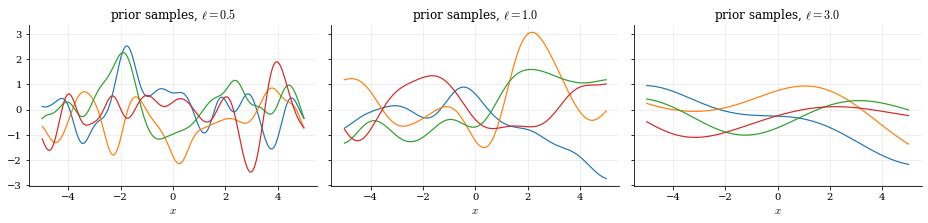

In [3]:
def se_kernel(X1, X2, ell=1.0, sf=1.0):
    """Squared-exponential kernel between two sets of points (arrays of shape (n, d))."""
    X1, X2 = np.atleast_2d(X1), np.atleast_2d(X2)
    sq = np.sum(X1**2, 1)[:, None] + np.sum(X2**2, 1)[None, :] - 2.0 * X1 @ X2.T
    return sf**2 * np.exp(-0.5 * sq / ell**2)

x = np.linspace(-5, 5, 200)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, ell in zip(axes, [0.5, 1.0, 3.0]):
    K = se_kernel(x[:, None], x[:, None], ell) + 1e-8 * np.eye(len(x))
    L = np.linalg.cholesky(K)
    for _ in range(4):
        ax.plot(x, L @ rng.standard_normal(len(x)), lw=1.2)
    ax.set_title(rf"prior samples, $\ell = {ell}$"); ax.set_xlabel("$x$")
fig.tight_layout(); savefig(fig, "gp_prior_samples"); plt.show()

---
## 2. The posterior in two lines

Stack the training values $\mathbf f$ and the test values $\mathbf f_*$ into one Gaussian vector and
condition on the observed ones:

$$\boldsymbol\mu_* = K_*^\top K^{-1} \mathbf f, \qquad
\Sigma_* = K_{**} - K_*^\top K^{-1} K_*, \qquad K_{ij} = k(x_i, x_j).$$

$K^{-1}$ is never formed: one Cholesky factorization of $K$ and two triangular solves.

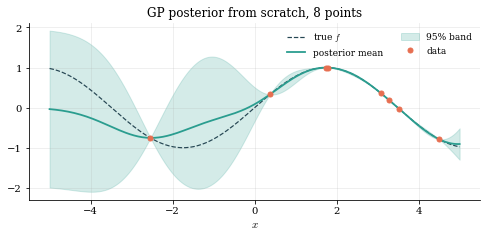

the band is zero at every data point and widest between them: the GP knows where it has not looked


In [4]:
def gp_posterior(X_tr, y_tr, X_te, ell=1.0, sf=1.0, noise=1e-8):
    """Posterior mean and standard deviation at X_te, given (X_tr, y_tr)."""
    K   = se_kernel(X_tr, X_tr, ell, sf) + noise * np.eye(len(X_tr))
    Ks  = se_kernel(X_tr, X_te, ell, sf)
    Kss = se_kernel(X_te, X_te, ell, sf)
    L = cho_factor(K, lower=True)
    mu = Ks.T @ cho_solve(L, y_tr)
    var = np.diag(Kss - Ks.T @ cho_solve(L, Ks))
    return mu, np.sqrt(np.maximum(var, 0.0))

f_smooth = lambda x: np.sin(0.9 * x)
X_tr = np.sort(rng.uniform(-5, 5, 8))
y_tr = f_smooth(X_tr)

mu, sd = gp_posterior(X_tr[:, None], y_tr, x[:, None], ell=1.0)
fig, ax = plt.subplots(figsize=(7, 3.4))
plot_gp(ax, x, mu, sd, X_tr, y_tr, f_smooth, "GP posterior from scratch, 8 points")
ax.legend(frameon=False, ncol=2); fig.tight_layout(); savefig(fig, "gp_posterior"); plt.show()
print("the band is zero at every data point and widest between them: the GP knows where it has not looked")

---
## 3. The length scale, and noise

With the length scale too short the posterior mean returns to the prior mean between the points,
which is a perfect training fit and a useless prediction. Too long, and the mean no longer passes
through the data while the band stays narrow: confidently wrong, the worse failure. With noisy
labels the diagonal of $K$ gets $\sigma_y^2$ added and the posterior smooths through the points;
even with exact labels a small jitter on the diagonal keeps the Cholesky factorization stable.

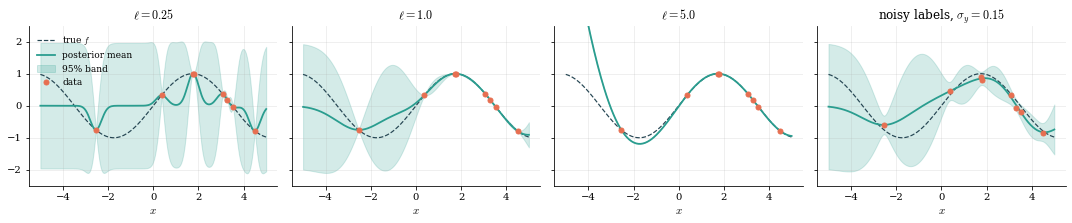

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
for ax, ell in zip(axes[:3], [0.25, 1.0, 5.0]):
    mu, sd = gp_posterior(X_tr[:, None], y_tr, x[:, None], ell=ell)
    plot_gp(ax, x, mu, sd, X_tr, y_tr, f_smooth, rf"$\ell = {ell}$")
y_noisy = y_tr + 0.15 * rng.standard_normal(len(y_tr))
mu, sd = gp_posterior(X_tr[:, None], y_noisy, x[:, None], ell=1.0, noise=0.15**2)
plot_gp(axes[3], x, mu, sd, X_tr, y_noisy, f_smooth, r"noisy labels, $\sigma_y = 0.15$")
axes[0].legend(frameon=False); axes[0].set_ylim(-2.5, 2.5)
fig.tight_layout(); savefig(fig, "gp_length_scale"); plt.show()

---
## 4. scikit-learn: hyperparameters by marginal likelihood

The hyperparameters $(\sigma_f, \ell)$ are chosen by maximizing

$$\log p(\mathbf y \mid X) = -\tfrac12 \mathbf y^\top K_y^{-1} \mathbf y - \tfrac12 \log|K_y| - \tfrac{N}{2}\log 2\pi,$$

a data-fit term against a complexity penalty, with no validation split. `GaussianProcessRegressor`
does this with restarts. The same call on a **kinked** target shows why the Matérn family is the
usual default for value and policy functions: the squared-exponential kernel assumes infinitely
many derivatives and rings around the kink; Matérn 3/2 assumes one.

fitted kernel: 1.07**2 * RBF(length_scale=2.26), log marginal likelihood 11.88
numpy posterior at the fitted hyperparameters agrees with scikit-learn to 4.4e-12


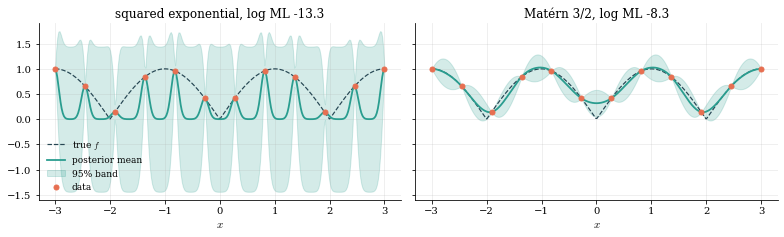

In [6]:
gp_sk = GaussianProcessRegressor(ConstantKernel(1.0) * RBF(1.0), alpha=1e-8, n_restarts_optimizer=5, random_state=SEED)
gp_sk.fit(X_tr[:, None], y_tr)
mu_sk, sd_sk = gp_sk.predict(x[:, None], return_std=True)
mu_np, sd_np = gp_posterior(X_tr[:, None], y_tr, x[:, None], ell=gp_sk.kernel_.k2.length_scale, sf=np.sqrt(gp_sk.kernel_.k1.constant_value))
print(f"fitted kernel: {gp_sk.kernel_}, log marginal likelihood {gp_sk.log_marginal_likelihood_value_:.2f}")
print(f"numpy posterior at the fitted hyperparameters agrees with scikit-learn to {np.abs(mu_sk - mu_np).max():.1e}")

f_kink = lambda x: np.abs(np.sin(np.pi * x / 2))
X_k = np.linspace(-3, 3, 12); y_k = f_kink(X_k)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, kern, name in zip(axes, [RBF(1.0), Matern(1.0, nu=1.5)], ["squared exponential", "Matérn 3/2"]):
    g = GaussianProcessRegressor(ConstantKernel(1.0) * kern, alpha=1e-8, n_restarts_optimizer=5, random_state=SEED).fit(X_k[:, None], y_k)
    xk = np.linspace(-3, 3, 300)
    m, s = g.predict(xk[:, None], return_std=True)
    plot_gp(ax, xk, m, s, X_k, y_k, f_kink, f"{name}, log ML {g.log_marginal_likelihood_value_:.1f}")
axes[0].legend(frameon=False); fig.tight_layout(); savefig(fig, "gp_kernel_kink"); plt.show()

---
## 5. Two inputs, one length scale each

The 40-point design of Notebook 1 (saved there as `qoi_design.npz`) maps $(\beta, \varrho)$ to the
mean capital stock. A Matérn 5/2 kernel with a separate length scale per input (automatic relevance
determination) learns how far each parameter reaches; the ratio of the two length scales is a
first sensitivity analysis for free.

In [7]:
d = np.load("qoi_design.npz")
BOX_LO, BOX_HI = np.array([0.92, 0.50]), np.array([0.99, 0.99])
u_design = (d["theta_design"][:40] - BOX_LO) / (BOX_HI - BOX_LO)
u_test   = (d["theta_test"] - BOX_LO) / (BOX_HI - BOX_LO)
y_design, y_test = d["q_design"][:40, 0], d["q_test"][:, 0]
mu_y, sd_y = y_design.mean(), y_design.std()

gp2 = GaussianProcessRegressor(ConstantKernel(1.0) * Matern([0.3, 0.3], nu=2.5), alpha=1e-8, n_restarts_optimizer=5, random_state=SEED)
gp2.fit(u_design, (y_design - mu_y) / sd_y)
m2, s2 = gp2.predict(u_test, return_std=True)
m2, s2 = m2 * sd_y + mu_y, s2 * sd_y
ls = gp2.kernel_.k2.length_scale
print(f"length scales in box units: beta {ls[0]:.2f}, rho {ls[1]:.2f}  (a longer scale means the output varies less along that input)")
print(f"test error of mean capital: mean {np.abs(m2 - y_test).mean():.2e}, max {np.abs(m2 - y_test).max():.2e}, "
      f"range on the design {y_design.max() - y_design.min():.2f}; 95% band coverage {100*np.mean(np.abs(m2 - y_test) <= 1.96 * s2):.0f}%")

length scales in box units: beta 8.57, rho 5.36  (a longer scale means the output varies less along that input)
test error of mean capital: mean 4.11e-03, max 9.80e-02, range on the design 3.47; 95% band coverage 92%


---
## 6. Active learning

With the kernel fixed, the posterior variance depends on the design alone, not on the labels, so
it can be consulted *before* the next label is paid for: query the point where the band is widest,
refit, repeat. The target is the Runge function $f(x) = 1/(1 + 25x^2)$ on $[-1, 1]$, the design
starts from the two endpoints, and the kernel is a squared exponential with $\ell = 0.3$ held fixed.
Each panel marks the point the rule chooses next.

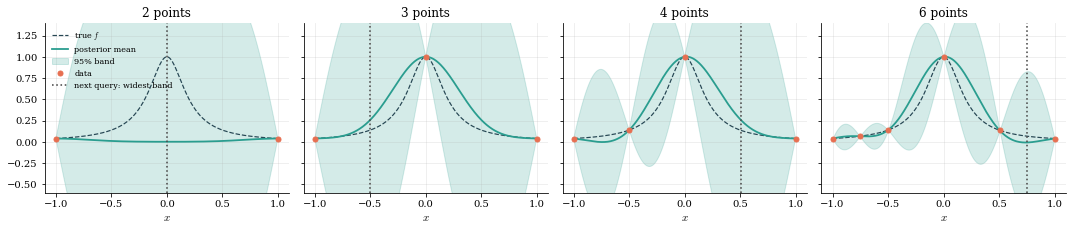

design after the loop: [-1.   -0.76 -0.5   0.    0.23  0.51  0.76  1.  ]
8 points: mean absolute error 0.0718 with active learning, 0.0434 with a uniform design


In [8]:
f_runge = lambda x: 1.0 / (1.0 + 25.0 * x**2)
x_c = np.linspace(-1, 1, 401)
ELL, N_FINAL = 0.3, 8

X_a, y_a = np.array([-1.0, 1.0]), f_runge(np.array([-1.0, 1.0]))
snapshots = {}
for it in range(N_FINAL - 2):
    mu, sd = gp_posterior(X_a[:, None], y_a, x_c[:, None], ell=ELL, noise=1e-6)
    sd[np.isin(x_c, X_a)] = -1.0                               # never re-query a point already in the design
    x_new = x_c[np.argmax(sd)]
    if len(X_a) in (2, 3, 4, 6):
        snapshots[len(X_a)] = (X_a.copy(), y_a.copy(), mu, np.maximum(sd, 0), x_new)
    X_a, y_a = np.append(X_a, x_new), np.append(y_a, f_runge(x_new))

fig, axes = plt.subplots(1, 4, figsize=(15, 3.3), sharey=True)
for ax, (n, (Xs, ys, mu, sd, x_new)) in zip(axes, snapshots.items()):
    plot_gp(ax, x_c, mu, sd, Xs, ys, f_runge, f"{n} points")
    ax.axvline(x_new, color="0.3", ls=":", lw=1.6, label="next query: widest band")
    ax.set_ylim(-0.6, 1.4)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout(); savefig(fig, "gp_active_learning"); plt.show()

print("design after the loop:", np.round(np.sort(X_a), 2))
mu_b, _ = gp_posterior(X_a[:, None], y_a, x_c[:, None], ell=ELL, noise=1e-6)
X_u = np.linspace(-1, 1, N_FINAL)
mu_u, _ = gp_posterior(X_u[:, None], f_runge(X_u), x_c[:, None], ell=ELL, noise=1e-6)
print(f"{N_FINAL} points: mean absolute error {np.abs(mu_b - f_runge(x_c)).mean():.4f} with active learning, "
      f"{np.abs(mu_u - f_runge(x_c)).mean():.4f} with a uniform design")

The rule fills the interval: after the endpoints it takes the centre, then the quarter points,
and so on, because for a stationary kernel the widest band is always the largest gap in the design.
On an interval that is the uniform design, reached one point at a time; the errors at the end are
close for that reason. What the loop buys is the same behaviour where no uniform design is
available: an irregular domain, a kernel with different length scales per input, or more inputs
than a grid can fill.

## 7. What to remember

1. **The kernel is the model.** It states how smooth the function is and over what distance
   inputs inform each other; everything else is conditioning a Gaussian.
2. **Two lines and one Cholesky factorization.** No training loop, no learning rate, and a
   posterior variance that vanishes at the data and returns to the prior away from it.
3. **Hyperparameters by marginal likelihood**, on the training data alone; Matérn rather than
   squared-exponential when the target may have a kink.
4. **One length scale per input** is a sensitivity analysis; the posterior variance is a sampling
   plan that fills the largest gap in the design. Both come free, and neither comes from a network.

In [9]:
print(f"RUN_MODE = {RUN_MODE}; notebook wall-clock {time.perf_counter()-T_NOTEBOOK:.0f} s")

RUN_MODE = teaching; notebook wall-clock 13 s
